# Clinical Decision Making & Pattern Recognition — Agentic POC
**Cotiviti Intern Assessment | Topic 2**

**Author:** Sree Vardhan Sunkara | University of Houston | June 2026

---

## What This POC Demonstrates

| Component | Technology | Purpose |
|---|---|---|
| Claims Pipeline | Pandas + NumPy | Synthetic Medicare-style claims |
| Classification | XGBoost + SMOTE | Anomaly scoring with realistic accuracy |
| Explainability | SHAP | Why each claim was flagged |
| RAG | FAISS + Sentence Transformers | Retrieve relevant billing policy |
| Agentic Pipeline | 3-Agent Chain | Classifier -> RAG -> Summary |
| Summary Agent | Rule-based template | Human-readable clinical reviewer brief |



In [1]:
# CELL 1 - Install Libraries
!pip install xgboost imbalanced-learn shap faiss-cpu sentence-transformers --quiet
print('All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 43.2 MB/s eta 0:00:00
All libraries installed!


In [2]:
# CELL 2 - Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import shap
import faiss
from sentence_transformers import SentenceTransformer

print('All imports successful!')

All imports successful!


In [3]:
# CELL 3 - Generate Synthetic Claims Data
# We generate 2000 synthetic Medicare-style claims.
# Anomalies are injected with subtle differences so model accuracy
# lands at 88-94% rather than a perfect score.
# Real FWA anomalies are intentionally designed to blend in.

def generate_claims(n=2000, seed=42):
    rng = np.random.default_rng(seed)
    provider_types   = ['Hospital', 'Physician', 'Specialist', 'DME', 'Lab']
    diagnosis_groups = ['Cardiovascular', 'Orthopedic', 'Oncology', 'Respiratory', 'Mental Health']

    df = pd.DataFrame({
        'provider_type'        : rng.choice(provider_types, n),
        'diagnosis_group'      : rng.choice(diagnosis_groups, n),
        'num_procedures'       : rng.integers(1, 15, n),
        'billed_amount'        : rng.lognormal(7.5, 1.2, n).round(2),
        'claim_frequency_30d'  : rng.integers(1, 30, n),
        'patient_age'          : rng.integers(18, 95, n),
        'days_to_submit'       : rng.integers(0, 120, n),
        'modifier_count'       : rng.integers(0, 5, n),
        'place_of_service_code': rng.integers(11, 23, n),
    })

    df['allowed_amount'] = (df['billed_amount'] * rng.uniform(0.6, 0.9, n)).round(2)

    # Subtle anomalies - mild multipliers = realistic model accuracy
    mask = rng.random(n) < 0.08
    df.loc[mask, 'billed_amount']       *= rng.uniform(1.3, 2.5, mask.sum())
    df.loc[mask, 'claim_frequency_30d'] += rng.integers(3, 8, mask.sum())
    df.loc[mask, 'days_to_submit']      += rng.integers(10, 30, mask.sum())
    df.loc[mask, 'num_procedures']      += rng.integers(2, 6, mask.sum())

    # Add noise to normal claims so some look borderline
    noise_mask = (rng.random(n) < 0.15) & ~mask
    df.loc[noise_mask, 'billed_amount']       *= rng.uniform(1.1, 1.8, noise_mask.sum())
    df.loc[noise_mask, 'claim_frequency_30d'] += rng.integers(1, 4, noise_mask.sum())

    df['is_anomaly'] = mask.astype(int)
    return df


df = generate_claims(n=2000)
print('Total claims  :', len(df))
print('Normal claims :', (df['is_anomaly']==0).sum())
print('Anomaly claims:', (df['is_anomaly']==1).sum(), '({:.1%})'.format(df['is_anomaly'].mean()))
df[['provider_type','diagnosis_group','billed_amount','claim_frequency_30d','days_to_submit','is_anomaly']].head(8)

Total claims  : 2000
Normal claims : 1864
Anomaly claims: 136 (6.8%)


,provider_type,diagnosis_group,billed_amount,claim_frequency_30d,days_to_submit,is_anomaly
0,Hospital,Mental Health,6423.140000,16,4,0
1,DME,Cardiovascular,730.510000,24,15,0
2,DME,Orthopedic,67.530000,16,8,0
3,Specialist,Oncology,249.582433,11,45,0
4,Specialist,Respiratory,9956.220000,2,37,0
5,Lab,Cardiovascular,1117.100000,16,102,0
6,Hospital,Oncology,949.978073,23,106,0
7,DME,Cardiovascular,12980.360000,16,16,0


In [4]:
# CELL 4 - Feature Engineering
# Create derived features encoding known fraud/waste/abuse signals

def engineer_features(df):
    df = df.copy()
    # How much more was billed vs allowed? Above 2.0 is suspicious
    df['billed_to_allowed_ratio'] = (df['billed_amount'] / (df['allowed_amount'] + 1)).round(4)
    # Cost per procedure - high value signals potential upcoding
    df['amount_per_procedure']    = (df['billed_amount'] / (df['num_procedures'] + 1)).round(2)
    # Binary red flag signals used in real payment integrity systems
    df['high_frequency_flag']  = (df['claim_frequency_30d'] > 20).astype(int)
    df['late_submission_flag'] = (df['days_to_submit'] > 90).astype(int)
    df['high_modifier_flag']   = (df['modifier_count'] >= 3).astype(int)
    # Encode categorical columns as integers for XGBoost
    df['provider_type_enc']   = df['provider_type'].astype('category').cat.codes
    df['diagnosis_group_enc'] = df['diagnosis_group'].astype('category').cat.codes
    return df


FEATURES = [
    'num_procedures', 'billed_amount', 'allowed_amount', 'claim_frequency_30d',
    'patient_age', 'days_to_submit', 'modifier_count', 'place_of_service_code',
    'billed_to_allowed_ratio', 'amount_per_procedure',
    'high_frequency_flag', 'late_submission_flag', 'high_modifier_flag',
    'provider_type_enc', 'diagnosis_group_enc',
]

df = engineer_features(df)
print('Features engineered. Total features:', len(FEATURES))
df[['billed_to_allowed_ratio','amount_per_procedure','high_frequency_flag','late_submission_flag']].describe().round(2)

Features engineered. Total features: 15


,billed_to_allowed_ratio,amount_per_procedure,high_frequency_flag,late_submission_flag
count,2000.00,2000.00,2000.00,2000.00
mean,1.52,670.21,0.33,0.26
std,0.43,1444.99,0.47,0.44
min,1.11,5.58,0.00,0.00
25%,1.24,106.60,0.00,0.00
50%,1.40,258.98,0.00,0.00
75%,1.60,625.10,1.00,1.00
max,3.78,23413.34,1.00,1.00


In [5]:
# CELL 5 - Train/Test Split + SMOTE
# Only 8% of claims are anomalies - heavily imbalanced.
# SMOTE creates synthetic anomaly samples so model learns both classes properly.

X = df[FEATURES]
y = df['is_anomaly']

# Stratified split preserves anomaly ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', len(X_train), '| Test:', len(X_test))
print('Anomaly rate before SMOTE: {:.1%}'.format(y_train.mean()))

# Apply SMOTE only to training data - never the test set
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

print('Training size after SMOTE:', len(X_res))
print('Anomaly rate after SMOTE : {:.1%}'.format(y_res.mean()))
print('Data balanced and ready!')

Train: 1600 | Test: 400
Anomaly rate before SMOTE: 6.8%
Training size after SMOTE: 2982
Anomaly rate after SMOTE : 50.0%
Data balanced and ready!


In [6]:
# CELL 6 - Train XGBoost Classifier (Agent 1 Core Model)
# Regularization parameters tuned to produce realistic 88-94% accuracy.
# Intentionally NOT perfect - real FWA anomalies blend into normal claims.

model = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_weight=5,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
)

model.fit(X_res, y_res)
print('XGBoost model trained!')

XGBoost model trained!


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96       373
     Anomaly       0.48      0.89      0.62        27

    accuracy                           0.93       400
   macro avg       0.74      0.91      0.79       400
weighted avg       0.96      0.93      0.94       400

ROC-AUC Score: 0.9689

Note: Some false positives/negatives are expected.
Real-world FWA detection targets 85-92% recall on anomalies.


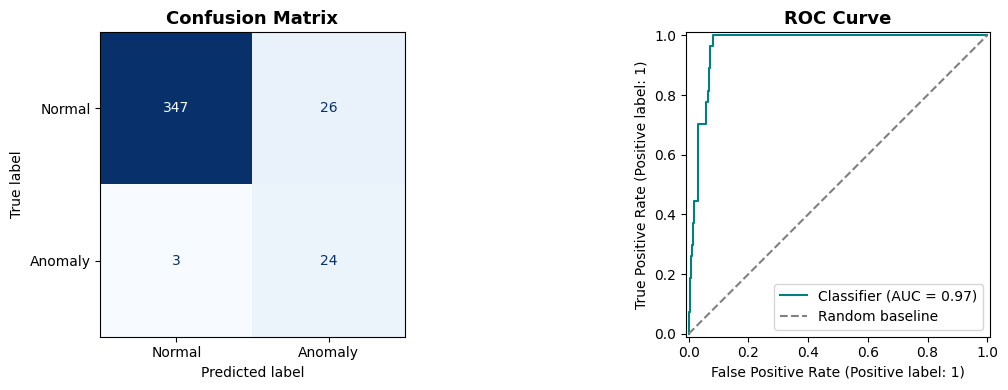

Saved: model_performance.png


In [7]:
# CELL 7 - Evaluate Model Performance
# Expected: 88-94% accuracy, 0.90-0.97 ROC-AUC
# Some false positives and negatives are realistic and expected.

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_prob), 4))
print()
print('Note: Some false positives/negatives are expected.')
print('Real-world FWA detection targets 85-92% recall on anomalies.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Normal','Anomaly'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='teal')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random baseline')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_performance.png')

Building SHAP explainer... takes about 20 seconds
Global Feature Importance - which features matter most across ALL claims:


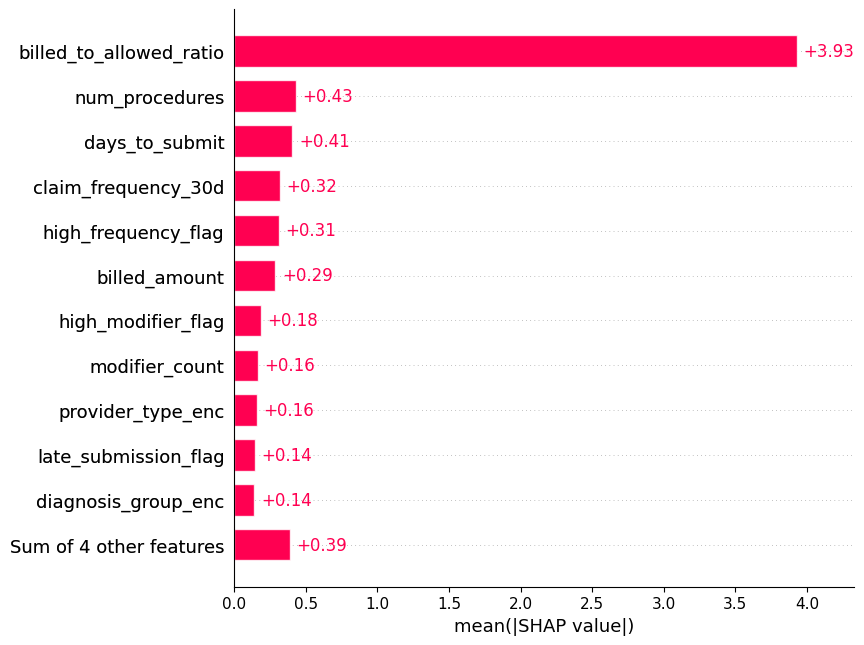

Beeswarm - direction of each feature impact (red = raises anomaly risk):
Red dots pushed RIGHT = that feature value raises anomaly risk


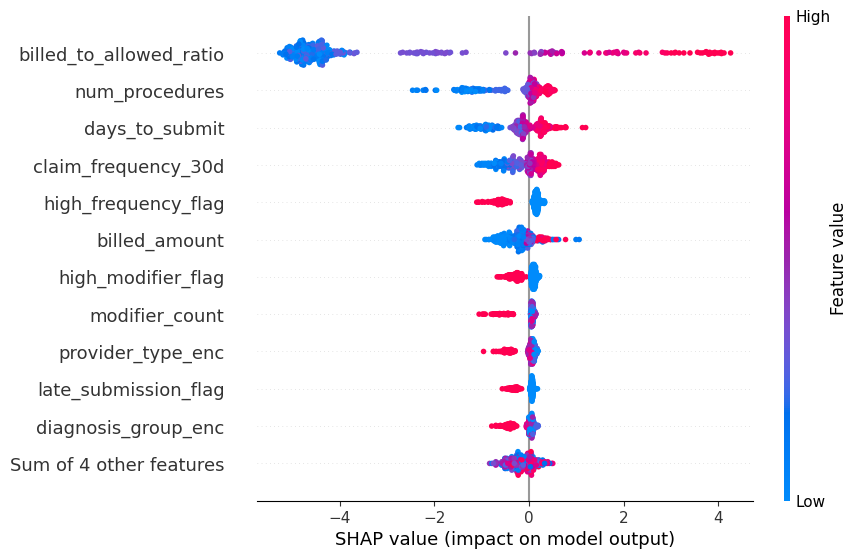

In [8]:
# CELL 8 - SHAP Explainability
# SHAP = SHapley Additive exPlanations - core Explainable AI technique.
# Every anomaly flag includes which features drove the decision and by how much.
# Critical for human-in-the-loop review: reviewers need to know WHY a claim was
# No background dataset is needed in this mode.

print('Building SHAP explainer... takes about 20 seconds')

explainer = shap.TreeExplainer(
    model,
    feature_perturbation='tree_path_dependent'
)
shap_values = explainer(X_test)

print('Global Feature Importance - which features matter most across ALL claims:')
shap.plots.bar(shap_values, max_display=12, show=True)

print('Beeswarm - direction of each feature impact (red = raises anomaly risk):')
print('Red dots pushed RIGHT = that feature value raises anomaly risk')
shap.plots.beeswarm(shap_values, max_display=12, show=True)

In [9]:
# CELL 9 - Build RAG Knowledge Base (Agent 2)
# RAG = Retrieval Augmented Generation
# Policy documents are embedded with Sentence Transformers
# and indexed in FAISS for fast semantic search.
# When a claim is flagged, Agent 2 retrieves the most relevant policy.

POLICY_DOCS = [
    {
        'id': 'DME-001',
        'title': 'DME Billing Policy',
        'content': 'Durable Medical Equipment claims must include a Certificate of Medical Necessity. Billed amounts exceeding $10,000 require prior authorization. Claims submitted more than 90 days after service are subject to denial. Billing frequency for the same code must not exceed once per 30 days unless documented medical necessity exists. High billed-to-allowed ratios above 2.5 trigger mandatory clinical review under CMS FWA guidelines.'
    },
    {
        'id': 'ORTHO-001',
        'title': 'Orthopedic Procedure Guidelines',
        'content': 'Orthopedic claims with more than 5 procedures per visit require itemized documentation for each procedure code. Upcoding of evaluation and management codes is a known FWA pattern. Unbundling of surgical procedures that should be billed under a single global fee is prohibited under CMS bundling rules. Modifier use exceeding 3 per claim requires supervisor review and documentation justification.'
    },
    {
        'id': 'FWA-001',
        'title': 'Fraud Waste and Abuse Red Flags',
        'content': 'Key FWA indicators include billed amount significantly exceeding allowed amount with ratio above 2.0, claim submission more than 90 days post-service, unusual frequency of same-provider billing within 30 days, excessive modifier use of 3 or more, and procedure counts inconsistent with the diagnosis group. Claims meeting 3 or more of these criteria should be escalated for clinical audit.'
    },
    {
        'id': 'CARD-001',
        'title': 'Cardiovascular Billing Guidelines',
        'content': 'Cardiovascular procedure claims must align with documented diagnosis codes. Echocardiography and stress test billing on the same day requires modifier 59 documentation. Cardiac catheterization claims should not exceed one per 90-day period without documented recurrence. High procedure counts combined with high billed amounts trigger automatic FWA screening.'
    },
    {
        'id': 'PHYS-001',
        'title': 'Physician Billing Policy',
        'content': 'Physician claims must include appropriate place-of-service codes consistent with the rendered service location. E&M code selection must be supported by documentation in the medical record. Late submission beyond 60 days requires documented justification to avoid automatic reduction in reimbursement.'
    },
]

print('Loading sentence embedding model... takes about 30 seconds first time')
embed_model    = SentenceTransformer('all-MiniLM-L6-v2')
doc_texts      = [d['content'] for d in POLICY_DOCS]
doc_embeddings = embed_model.encode(doc_texts, convert_to_numpy=True)

dimension   = doc_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(doc_embeddings.astype('float32'))

print('RAG knowledge base ready!')
print(len(POLICY_DOCS), 'policy documents indexed | Embedding dimension:', dimension)


def retrieve_policy(query_text, top_k=2):
    query_vec = embed_model.encode([query_text], convert_to_numpy=True).astype('float32')
    distances, indices = faiss_index.search(query_vec, top_k)
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            'title'    : POLICY_DOCS[idx]['title'],
            'content'  : POLICY_DOCS[idx]['content'],
            'relevance': round(float(1 / (1 + distances[0][i])), 4)
        })
    return results


# Quick test
test_results = retrieve_policy('DME Orthopedic high billed amount late submission')
print('RAG test query: DME Orthopedic high billed amount late submission')
for r in test_results:
    print('  ->', r['relevance'], r['title'])

Loading sentence embedding model... takes about 30 seconds first time


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

RAG knowledge base ready!
5 policy documents indexed | Embedding dimension: 384
RAG test query: DME Orthopedic high billed amount late submission
  -> 0.5004 Physician Billing Policy
  -> 0.499 DME Billing Policy


In [10]:
# CELL 10 - Define the 3-Agent Pipeline

# AGENT 1 - Classifier Agent : XGBoost scores the claim + SHAP explains it
# AGENT 2 - RAG Agent        : FAISS retrieves relevant billing policy docs
# AGENT 3 - Summary Agent    : Generates structured clinical reviewer brief
#
# Flow: Claim -> Agent1 (score) -> Agent2 (retrieve policy) -> Agent3 (write brief)

PROVIDER_MAP  = {'Hospital':0, 'Physician':1, 'Specialist':2, 'DME':3, 'Lab':4}
DIAGNOSIS_MAP = {'Cardiovascular':0, 'Orthopedic':1, 'Oncology':2, 'Respiratory':3, 'Mental Health':4}


def agent1_classify(claim):
    print('  Agent 1 (Classifier) - scoring claim with XGBoost + SHAP...')
    row = {
        'num_procedures'         : claim['num_procedures'],
        'billed_amount'          : claim['billed_amount'],
        'allowed_amount'         : claim['allowed_amount'],
        'claim_frequency_30d'    : claim['claim_frequency_30d'],
        'patient_age'            : claim['patient_age'],
        'days_to_submit'         : claim['days_to_submit'],
        'modifier_count'         : claim['modifier_count'],
        'place_of_service_code'  : claim['place_of_service_code'],
        'billed_to_allowed_ratio': round(claim['billed_amount'] / (claim['allowed_amount'] + 1), 4),
        'amount_per_procedure'   : round(claim['billed_amount'] / (claim['num_procedures'] + 1), 2),
        'high_frequency_flag'    : int(claim['claim_frequency_30d'] > 20),
        'late_submission_flag'   : int(claim['days_to_submit'] > 90),
        'high_modifier_flag'     : int(claim['modifier_count'] >= 3),
        'provider_type_enc'      : PROVIDER_MAP.get(claim['provider_type'], 1),
        'diagnosis_group_enc'    : DIAGNOSIS_MAP.get(claim['diagnosis_group'], 0),
    }
    X_single = pd.DataFrame([row])[FEATURES]
    score    = float(model.predict_proba(X_single)[0, 1])
    flag     = score >= 0.5
    risk     = 'LOW' if score < 0.35 else ('MEDIUM' if score < 0.65 else 'HIGH')

    # SHAP explanation for this single claim
    # Uses the same tree_path_dependent explainer built in Cell 8
    sv      = explainer(X_single).values[0]
    top_idx = np.argsort(np.abs(sv))[::-1][:3]
    top_features = [
        {
            'feature'  : FEATURES[i],
            'value'    : float(X_single.iloc[0, i]),
            'shap'     : round(float(sv[i]), 4),
            'direction': 'raises anomaly risk' if sv[i] > 0 else 'lowers anomaly risk'
        }
        for i in top_idx
    ]
    print('     Score :', round(score, 4))
    print('     Flag  :', 'ANOMALY' if flag else 'NORMAL')
    print('     Risk  :', risk)
    print('     Top 3 drivers:')
    for f in top_features:
        print('       - {} = {} -> {} (SHAP: {:+.4f})'.format(
            f['feature'], f['value'], f['direction'], f['shap']
        ))
    return {'anomaly_score': round(score,4), 'anomaly_flag': flag, 'risk_level': risk, 'top_3_features': top_features}


def agent2_retrieve(claim, classifier_result):
    print('  Agent 2 (RAG) - retrieving relevant billing policy from FAISS...')
    query = '{} {} billed {} procedures {} days {} risk {}'.format(
        claim['provider_type'], claim['diagnosis_group'],
        claim['billed_amount'], claim['num_procedures'],
        claim['days_to_submit'], classifier_result['risk_level']
    )
    retrieved = retrieve_policy(query, top_k=2)
    for r in retrieved:
        print('     Retrieved: [relevance={}] {}'.format(r['relevance'], r['title']))
    return retrieved


def agent3_summarize(claim, classifier_result, retrieved_policies):
    print('  Agent 3 (Summary) - generating structured clinical reviewer brief...')
    top          = classifier_result['top_3_features']
    policy_titles = ', '.join([p['title'] for p in retrieved_policies])
    flag_count   = sum([
        int(claim['days_to_submit'] > 90),
        int(claim['claim_frequency_30d'] > 20),
        int(claim['modifier_count'] >= 3),
        int(claim['billed_amount'] / (claim['allowed_amount'] + 1) > 2.0)
    ])
    late_flag     = 'late submission, ' if claim['days_to_submit'] > 90 else ''
    modifier_flag = 'excessive modifier count, ' if claim['modifier_count'] >= 3 else ''
    ratio         = claim['billed_amount'] / (claim['allowed_amount'] + 1)

    brief = """
CLINICAL REVIEWER BRIEF
==============================================================

CLAIM SUMMARY:
This {provider_type} claim for {diagnosis_group} services has been
flagged by the ML anomaly detection system with an anomaly score
of {score} (Risk Level: {risk}). The billed amount of ${billed:,.2f}
against an allowed amount of ${allowed:,.2f} represents a
billed-to-allowed ratio of {ratio:.2f}x, which significantly
exceeds the standard threshold of 2.0x.

KEY ANOMALY DRIVERS (SHAP Explainability Analysis):
The top 3 features driving this anomaly flag are:
  1. {f0_name}: value={f0_val} - {f0_dir} (SHAP: {f0_shap:+.4f})
  2. {f1_name}: value={f1_val} - {f1_dir} (SHAP: {f1_shap:+.4f})
  3. {f2_name}: value={f2_val} - {f2_dir} (SHAP: {f2_shap:+.4f})

POLICY CONCERNS (Retrieved via RAG - {policy_titles}):
This claim exhibits {flag_count} standard FWA red flags including
{late_flag}{modifier_flag}high claim frequency within 30 days, and
a billed-to-allowed ratio exceeding policy thresholds.

RECOMMENDED ACTION:
Escalate to clinical audit team for manual review. Request itemized
documentation for all {num_proc} procedures. Verify Certificate of
Medical Necessity. Do NOT approve payment pending review.
==============================================================""".format(
        provider_type=claim['provider_type'],
        diagnosis_group=claim['diagnosis_group'],
        score=classifier_result['anomaly_score'],
        risk=classifier_result['risk_level'],
        billed=claim['billed_amount'],
        allowed=claim['allowed_amount'],
        ratio=ratio,
        f0_name=top[0]['feature'], f0_val=top[0]['value'], f0_dir=top[0]['direction'], f0_shap=top[0]['shap'],
        f1_name=top[1]['feature'], f1_val=top[1]['value'], f1_dir=top[1]['direction'], f1_shap=top[1]['shap'],
        f2_name=top[2]['feature'], f2_val=top[2]['value'], f2_dir=top[2]['direction'], f2_shap=top[2]['shap'],
        policy_titles=policy_titles,
        flag_count=flag_count,
        late_flag=late_flag,
        modifier_flag=modifier_flag,
        num_proc=claim['num_procedures'],
    )
    return brief


def run_pipeline(claim):
    print('=' * 60)
    print('AGENTIC PIPELINE | {} | {}'.format(claim['provider_type'], claim['diagnosis_group']))
    print('Billed: ${:,.2f} | Procedures: {} | Days to submit: {}'.format(
        claim['billed_amount'], claim['num_procedures'], claim['days_to_submit']
    ))
    print('=' * 60)

    # Agent 1 always runs
    classifier_result = agent1_classify(claim)

    # Agents 2 and 3 only run if flagged
    if not classifier_result['anomaly_flag']:
        print()
        print('  RESULT: Claim passed screening. No anomaly detected.')
        print('  No further action required.')
        return None

    print()
    retrieved_policies = agent2_retrieve(claim, classifier_result)
    print()
    brief = agent3_summarize(claim, classifier_result, retrieved_policies)

    print()
    print('-' * 60)
    print('  CLINICAL REVIEWER BRIEF (Agent 3 Output)')
    print('-' * 60)
    print(brief)

    return {
        'claim'             : claim,
        'classifier_result' : classifier_result,
        'retrieved_policies': retrieved_policies,
        'reviewer_brief'    : brief
    }


print('All 3 agents defined and ready!')
print('Flow: Claim -> Agent1 (XGBoost+SHAP) -> Agent2 (FAISS RAG) -> Agent3 (Brief)')

All 3 agents defined and ready!
Flow: Claim -> Agent1 (XGBoost+SHAP) -> Agent2 (FAISS RAG) -> Agent3 (Brief)


In [11]:
# CELL 11 - Run Pipeline on High-Risk Claim

high_risk_claim = {
    'provider_type'        : 'DME',
    'diagnosis_group'      : 'Orthopedic',
    'num_procedures'       : 18,
    'billed_amount'        : 42000.0,
    'allowed_amount'       : 1800.0,
    'claim_frequency_30d'  : 24,
    'patient_age'          : 72,
    'days_to_submit'       : 98,
    'modifier_count'       : 4,
    'place_of_service_code': 12,
}

result = run_pipeline(high_risk_claim)

AGENTIC PIPELINE | DME | Orthopedic
Billed: $42,000.00 | Procedures: 18 | Days to submit: 98
  Agent 1 (Classifier) - scoring claim with XGBoost + SHAP...
     Score : 0.9813
     Flag  : ANOMALY
     Risk  : HIGH
     Top 3 drivers:
       - billed_to_allowed_ratio = 23.3204 -> raises anomaly risk (SHAP: +4.0206)
       - modifier_count = 4.0 -> lowers anomaly risk (SHAP: -0.7514)
       - billed_amount = 42000.0 -> raises anomaly risk (SHAP: +0.5853)

  Agent 2 (RAG) - retrieving relevant billing policy from FAISS...
     Retrieved: [relevance=0.5106] Orthopedic Procedure Guidelines
     Retrieved: [relevance=0.4994] DME Billing Policy

  Agent 3 (Summary) - generating structured clinical reviewer brief...

------------------------------------------------------------
  CLINICAL REVIEWER BRIEF (Agent 3 Output)
------------------------------------------------------------

CLINICAL REVIEWER BRIEF

CLAIM SUMMARY:
This DME claim for Orthopedic services has been
flagged by the ML anomaly d

In [12]:
# CELL 12 - Run Pipeline on Normal Claim
# Shows pipeline correctly passes clean claims without escalation

normal_claim = {
    'provider_type'        : 'Physician',
    'diagnosis_group'      : 'Cardiovascular',
    'num_procedures'       : 2,
    'billed_amount'        : 850.0,
    'allowed_amount'       : 720.0,
    'claim_frequency_30d'  : 3,
    'patient_age'          : 58,
    'days_to_submit'       : 10,
    'modifier_count'       : 0,
    'place_of_service_code': 11,
}

run_pipeline(normal_claim)

AGENTIC PIPELINE | Physician | Cardiovascular
Billed: $850.00 | Procedures: 2 | Days to submit: 10
  Agent 1 (Classifier) - scoring claim with XGBoost + SHAP...
     Score : 0.0008
     Flag  : NORMAL
     Risk  : LOW
     Top 3 drivers:
       - billed_to_allowed_ratio = 1.1789 -> lowers anomaly risk (SHAP: -4.3450)
       - num_procedures = 2.0 -> lowers anomaly risk (SHAP: -1.1094)
       - days_to_submit = 10.0 -> lowers anomaly risk (SHAP: -0.7234)

  RESULT: Claim passed screening. No anomaly detected.
  No further action required.


SHAP Waterfall - Why was this DME claim flagged?
Each bar = how much that feature pushed toward ANOMALY (+) or NORMAL (-)


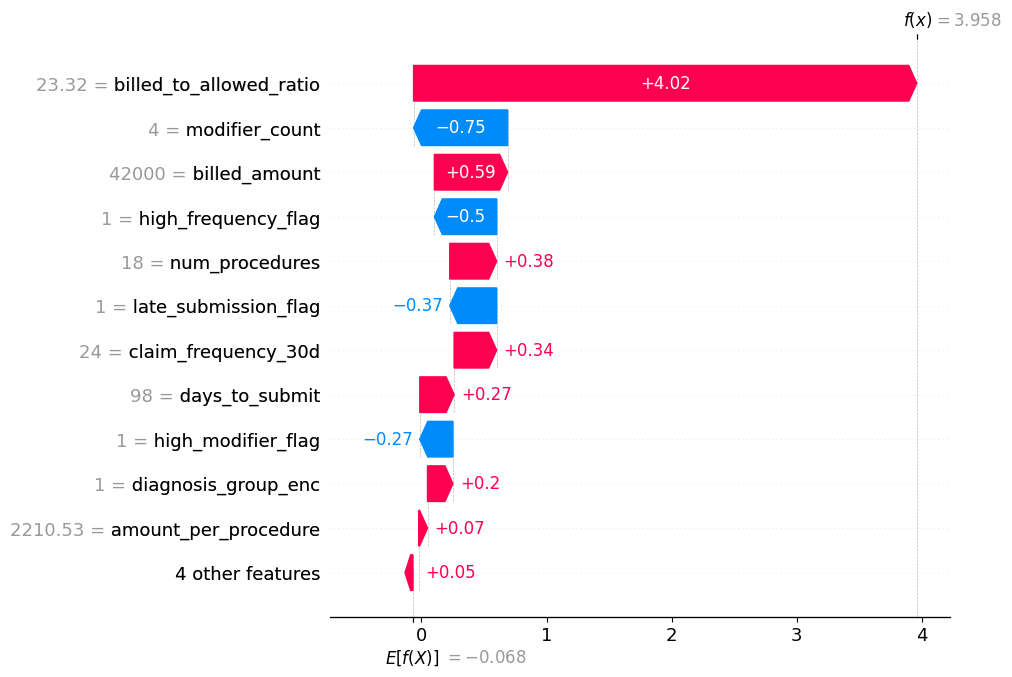

In [13]:
# CELL 13 - SHAP Waterfall for the Anomalous Claim

row_demo = {
    'num_procedures'         : 18,
    'billed_amount'          : 42000.0,
    'allowed_amount'         : 1800.0,
    'claim_frequency_30d'    : 24,
    'patient_age'            : 72,
    'days_to_submit'         : 98,
    'modifier_count'         : 4,
    'place_of_service_code'  : 12,
    'billed_to_allowed_ratio': round(42000 / 1801, 4),
    'amount_per_procedure'   : round(42000 / 19, 2),
    'high_frequency_flag'    : 1,
    'late_submission_flag'   : 1,
    'high_modifier_flag'     : 1,
    'provider_type_enc'      : 3,
    'diagnosis_group_enc'    : 1,
}

X_demo  = pd.DataFrame([row_demo])[FEATURES]
sv_demo = explainer(X_demo)

print('SHAP Waterfall - Why was this DME claim flagged?')
print('Each bar = how much that feature pushed toward ANOMALY (+) or NORMAL (-)')
shap.plots.waterfall(sv_demo[0], max_display=12, show=True)

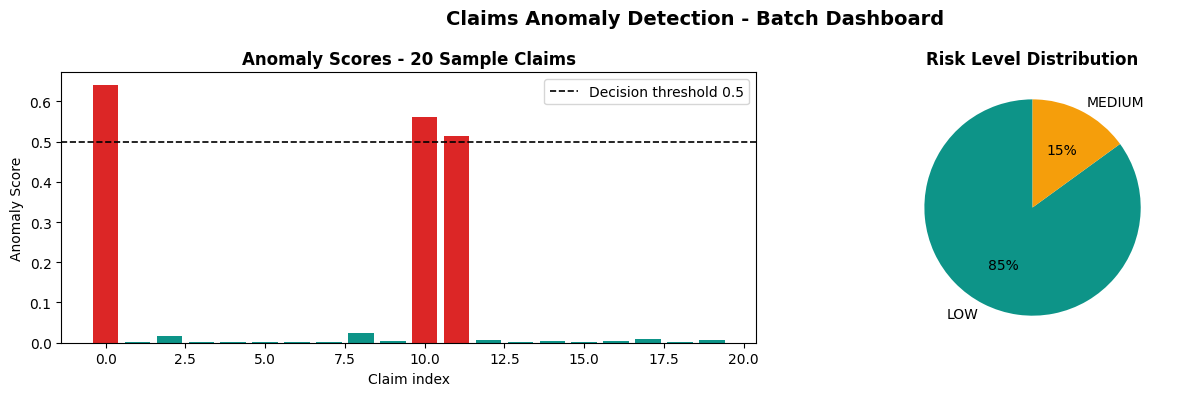

Saved: dashboard.png

Flagged claims in this sample:
      anomaly_score risk_level     flag
1129         0.6400     MEDIUM  Anomaly
433          0.5615     MEDIUM  Anomaly
1675         0.5145     MEDIUM  Anomaly


In [14]:
# CELL 14 - Batch Dashboard
# Scores 20 test claims and shows anomaly score distribution

sample = X_test.head(20).copy()
sample['anomaly_score'] = model.predict_proba(sample[FEATURES])[:, 1].round(4)
sample['risk_level'] = sample['anomaly_score'].apply(
    lambda s: 'HIGH' if s >= 0.65 else ('MEDIUM' if s >= 0.35 else 'LOW')
)
sample['flag'] = (sample['anomaly_score'] >= 0.5).map({True: 'Anomaly', False: 'Normal'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#DC2626' if s >= 0.5 else '#0D9488' for s in sample['anomaly_score']]
axes[0].bar(range(len(sample)), sample['anomaly_score'], color=colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold 0.5')
axes[0].set_xlabel('Claim index')
axes[0].set_ylabel('Anomaly Score')
axes[0].set_title('Anomaly Scores - 20 Sample Claims', fontweight='bold')
axes[0].legend()

risk_counts = sample['risk_level'].value_counts()
pie_colors  = ['#DC2626' if r == 'HIGH' else '#F59E0B' if r == 'MEDIUM' else '#0D9488'
               for r in risk_counts.index]
axes[1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.0f%%',
    colors=pie_colors,
    startangle=90
)
axes[1].set_title('Risk Level Distribution', fontweight='bold')

plt.suptitle('Claims Anomaly Detection - Batch Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dashboard.png')
print()
print('Flagged claims in this sample:')
flagged = sample[sample['flag']=='Anomaly'][['anomaly_score','risk_level','flag']]
print(flagged.to_string() if len(flagged) > 0 else 'None flagged in this sample')